In [145]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

# 1. Детекция автомобильных номеров

In [168]:
def number_detect(image, model, scaleFactor, minNeighbors):
    number_cascade = cv2.CascadeClassifier(model)
    img = cv2.imread(image, cv2.IMREAD_COLOR_RGB)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    numbers = number_cascade.detectMultiScale(img, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    for (x, y, w, h) in numbers:
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 0), 5)
    number = img[y:y + h, x:x + w]
    plt.imshow(number)
    plt.show()

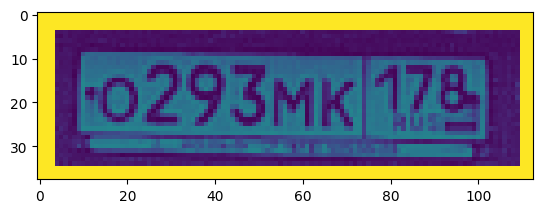

In [169]:
number_detect('number_1.jpg', 'haarcascade_russian_plate_number.xml', 1.1, 30)

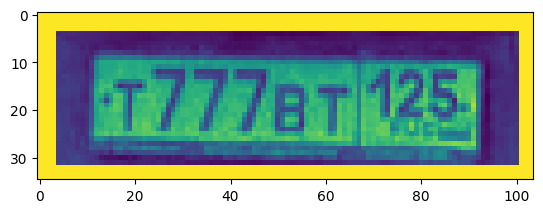

In [165]:
number_detect('number_2.jpg', 'haarcascade_russian_plate_number.xml', 1.1, 30)

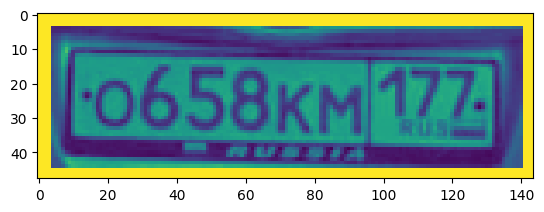

In [152]:
number_detect('number_3.jpg', 'haarcascade_russian_plate_number.xml', 1.1, 30)

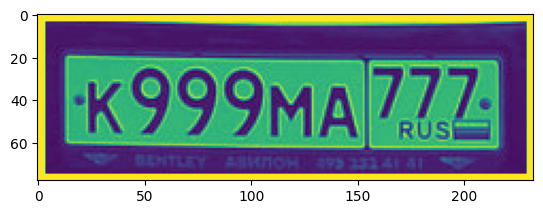

In [6]:
number_detect('number_4.jpg', 'haarcascade_russian_plate_number.xml', 1.1, 30)

# 2. Детекция изображений котов

In [7]:
def cat_detect(image, model, coef, scaleFactor, minNeighbors):
    cat_cascade = cv2.CascadeClassifier(model)
    img = cv2.imread(image, cv2.IMREAD_COLOR_RGB)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cats = cat_cascade.detectMultiScale(img, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    counter = 0
    for (x, y, w, h) in cats:
        cv2.rectangle(img, (x-coef, y-coef), (x+w+coef, y+h+coef), (255, 255, 0), 5)
        counter += 1
    print(counter)
    plt.imshow(img)
    plt.show()
    

2


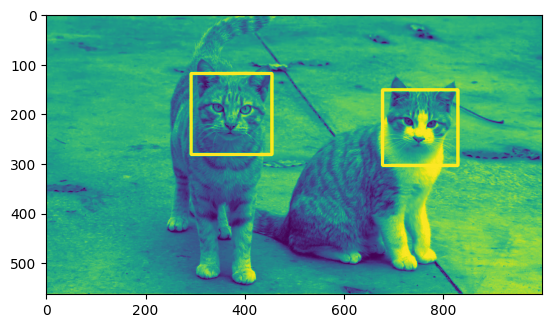

In [8]:
cat_detect('cat_1.jpg', 'haarcascade_frontalcatface.xml', 20, 1.1, 10)

2


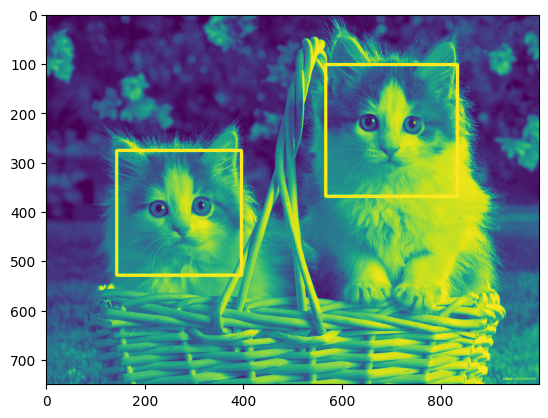

In [9]:
cat_detect('cat_2.jpg', 'haarcascade_frontalcatface.xml', 20, 1.1, 10)

1


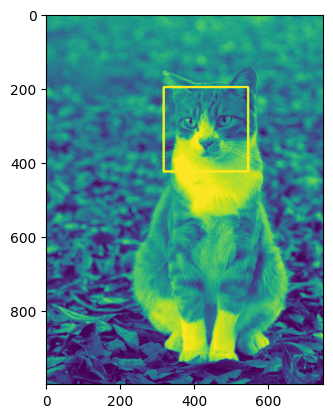

In [10]:
cat_detect('cat_3.jpg', 'haarcascade_frontalcatface.xml', 20, 1.1, 10)

In [68]:
def image_preparation(image, 
                      noise_type, 
                      threshold_type, 
                      contrast_type, 
                      x1, 
                      x2=None, 
                      x3=None, 
                      gaussian_size=None,
                      clip_limit=None,
                      tile_grid_size=None,
                      adaptive_window_size=None,
                      constant=None):
    
    img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    if noise_type == 'bilateral':
        img = cv2.bilateralFilter(img, x1, x2, x3)
    elif noise_type == 'gaussian':
        img = cv2.GaussianBlur(img, gaussian_size, x1)
    elif noise_type == 'median':
        img = cv2.medianBlur(img, x1)
    
    if threshold_type == 'binary':
        img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    elif threshold_type == 'adaptive':
        img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, adaptive_window_size, constant)

    if contrast_type == 'clahe':
        img = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size).apply(img)
    elif contrast_type == 'equalize':
        img = cv2.equalizeHist(img)

    return img

In [140]:
def clock_detect(img, model, scaleFactor, minNeighbors):
    clock_cascade = cv2.CascadeClassifier(model)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clocks = clock_cascade.detectMultiScale(img, scaleFactor=scaleFactor, minNeighbors=minNeighbors)
    for (x, y, w, h) in clocks:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 0), 8)
    clocks = img[y:y + h, x:x + w]
    plt.imshow(clocks)
    plt.show()

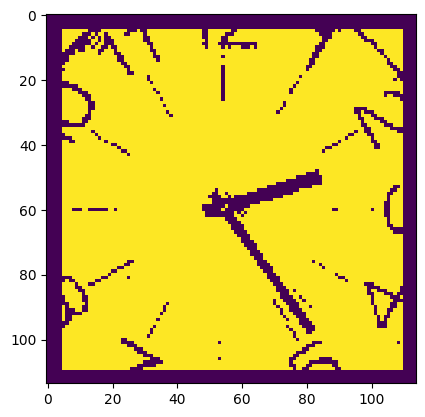

In [141]:
img = cv2.imread('clock1.jpg', cv2.IMREAD_COLOR_RGB)
img = image_preparation(img, 'bilateral', 'binary', 'equalize', 10, 30, 30)
clock_detect(img, 'haarcascade_wallclock.xml', 1.001, 30)

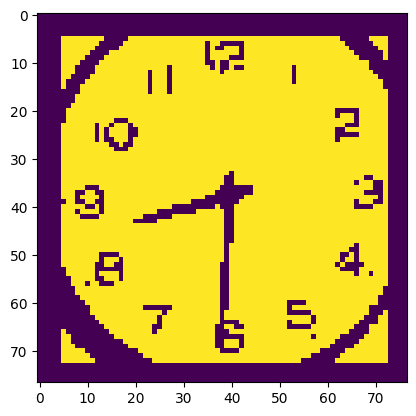

In [142]:
img = cv2.imread('clock2.jpg', cv2.IMREAD_COLOR_RGB)
img = image_preparation(img, 'bilateral', 'binary', 'equalize', 10, 30, 30)
clock_detect(img, 'haarcascade_wallclock.xml', 1.01, 20)

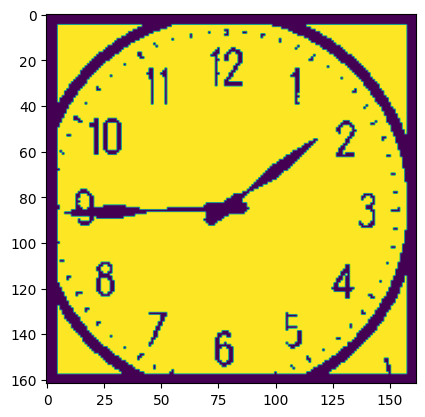

In [143]:
img = cv2.imread('clock3.jpg', cv2.IMREAD_COLOR_RGB)
img = image_preparation(img, 'bilateral', 'binary', 'equalize', 10, 30, 30)
clock_detect(img, 'haarcascade_wallclock.xml', 1.01, 30)

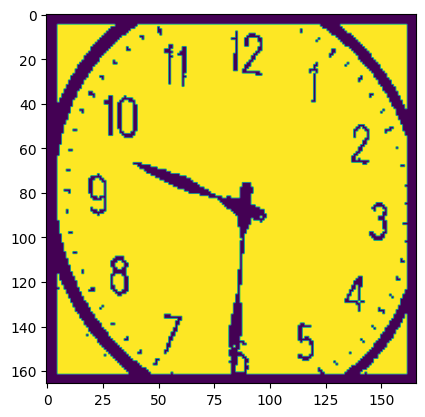

In [144]:
img = cv2.imread('clock4.jpg', cv2.IMREAD_COLOR_RGB)
img = image_preparation(img, 'bilateral', 'binary', 'equalize', 10, 30, 30)
clock_detect(img, 'haarcascade_wallclock.xml', 1.01, 50)